# Praktikum Teknik Peramalan
## Metode Holt pada Data Bulanan

**Nama:** Ade Nafil Firmansah  
**NIM:** 3012210002  
**Metode:** Holt's Double Exponential Smoothing  
**Dataset terpilih:** Airline Passengers  
**Sumber:** https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

### Ringkasan Praktikum
Notebook ini membangun pipeline peramalan time series bulanan dengan struktur:
1. Import library
2. Load data Airline Passengers
3. Cleaning dan standardisasi menjadi kolom `date` dan `value`
4. Validasi kualitas data
5. Visualisasi time series
6. Train-test split yang time-aware
7. Fitting model Holt
8. Forecast 15 periode ke depan
9. Evaluasi error
10. Interpretasi hasil
11. Kesimpulan

### Deskripsi Dataset
Dataset `Airline Passengers` berisi jumlah penumpang pesawat per bulan dari Januari 1949 sampai Desember 1960.
Total observasi adalah 144 periode bulanan, sehingga memenuhi syarat minimum 100 observasi untuk praktikum ini.
Dataset ini univariat, rapi, dan cocok untuk demonstrasi metode Holt karena memiliki kecenderungan trend yang jelas.


## Sel 1 - Import Library

In [59]:
"""Import dependensi utama untuk analisis time series Holt.

Blok ini menyiapkan:
- manipulasi data dengan pandas dan numpy,
- visualisasi dengan matplotlib,
- pengambilan data CSV via HTTP,
- utilitas display untuk notebook,
- model Holt dari statsmodels jika tersedia.

Output utama:
- flag `STATSMODELS_AVAILABLE` untuk memilih jalur model,
- pengaturan gaya plot dan format angka agar hasil notebook konsisten.
"""
from __future__ import annotations

import warnings
from io import StringIO

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

warnings.filterwarnings("ignore")

try:
    from statsmodels.tsa.holtwinters import Holt
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    Holt = None

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"statsmodels  : {'tersedia' if STATSMODELS_AVAILABLE else 'tidak tersedia'}")
print("Import selesai.")


pandas       : 2.2.2
numpy        : 2.0.2
statsmodels  : tersedia
Import selesai.


## Sel 2 - Load Data

In [60]:
"""Muat dataset `Airline Passengers` dari sumber CSV publik.

Konstanta pada blok ini menjadi konfigurasi dasar notebook:
- `FORECAST_HORIZON` menentukan panjang forecast out-of-sample,
- `MIN_OBSERVATIONS` menjadi ambang validasi data,
- metadata dataset dipakai ulang pada bagian interpretasi dan README.

Fungsi:
- `fetch_text`: mengambil konten mentah dari URL dengan user-agent eksplisit.
- `load_standard_csv`: membaca CSV dan menormalkan nama kolom menjadi
  `date` dan `value`.
"""
FORECAST_HORIZON = 15
MIN_OBSERVATIONS = 100
DATASET_NAME = "Airline Passengers"
DATASET_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
DATASET_NOTES = "Dataset bulanan 1949-01 sampai 1960-12 dengan total 144 observasi."


def fetch_text(url: str, timeout: int = 30) -> str:
    """Ambil teks mentah dari URL sumber dataset.

    Args:
        url: Alamat sumber data.
        timeout: Batas waktu request dalam detik.

    Returns:
        Isi respons sebagai string.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/123.0 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=timeout)
    response.raise_for_status()
    return response.text


def load_standard_csv(url: str) -> pd.DataFrame:
    """Baca dataset CSV dua kolom dan standarkan menjadi `date` dan `value`.

    Args:
        url: Lokasi file CSV.

    Returns:
        DataFrame dengan dua kolom utama: `date` dan `value`.
    """
    text = fetch_text(url)
    df = pd.read_csv(StringIO(text))
    df.columns = [col.strip().lower() for col in df.columns]

    date_col = "month" if "month" in df.columns else df.columns[0]
    value_col = "passengers" if "passengers" in df.columns else df.columns[1]

    data = df[[date_col, value_col]].rename(columns={date_col: "date", value_col: "value"})
    return data


raw_df = load_standard_csv(DATASET_URL)
selected_dataset = DATASET_NAME

print(f"Dataset terpilih : {selected_dataset}")
print(f"Sumber           : {DATASET_URL}")
print(f"Catatan          : {DATASET_NOTES}")
print(f"Jumlah baris awal: {len(raw_df)}")

display(raw_df.head())


Dataset terpilih : Airline Passengers
Sumber           : https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Catatan          : Dataset bulanan 1949-01 sampai 1960-12 dengan total 144 observasi.
Jumlah baris awal: 144


,date,value
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Sel 3 - Cleaning dan Standardisasi

In [61]:
"""Bersihkan dan standarkan data mentah sebelum analisis.

Langkah yang dilakukan:
- menormalisasi nama kolom,
- memaksa struktur hanya menjadi `date` dan `value`,
- membersihkan karakter non-numerik pada target,
- mencoba beberapa format parsing tanggal,
- mengubah tanggal ke granularitas bulanan awal bulan,
- mengurutkan data dan membuang duplikasi bulan.

Output akhir pada blok ini adalah `df`, yaitu DataFrame siap analisis.
"""
df = raw_df.copy()
df.columns = [str(col).strip().lower() for col in df.columns]
df = df.rename(columns={df.columns[0]: "date", df.columns[1]: "value"})

# Normalisasi nilai mentah pada kolom tanggal dan target.
df["date"] = (
    df["date"]
    .astype(str)
    .str.strip()
    .replace({"nan": np.nan, "None": np.nan})
)

df["value"] = (
    df["value"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^0-9.\-]", "", regex=True)
)

# Coba beberapa format tanggal agar notebook lebih tahan terhadap variasi input.
date_parse_candidates = [
    pd.to_datetime(df["date"], errors="coerce"),
    pd.to_datetime(df["date"], format="%Y-%m", errors="coerce"),
    pd.to_datetime(df["date"], format="%Y/%m", errors="coerce"),
    pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce"),
    pd.to_datetime(df["date"], format="%b %Y", errors="coerce"),
    pd.to_datetime(df["date"], format="%B %Y", errors="coerce"),
]

best_dates = max(date_parse_candidates, key=lambda s: s.notna().sum())
df["date"] = best_dates
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Buang baris tidak valid, ubah ke frekuensi bulanan, lalu pastikan urutan waktu rapi.
df = df.dropna(subset=["date", "value"]).copy()
df["date"] = df["date"].dt.to_period("M").dt.to_timestamp()
df = df.sort_values("date").drop_duplicates(subset=["date"], keep="first")
df = df.reset_index(drop=True)

print("Data setelah cleaning:")
display(df.head())
display(df.tail())

print(f"Rentang waktu : {df['date'].min().date()} sampai {df['date'].max().date()}")
print(f"Jumlah data   : {len(df)} observasi")


Data setelah cleaning:


,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


Rentang waktu : 1949-01-01 sampai 1960-12-01
Jumlah data   : 144 observasi


## Sel 4 - Validasi Data

In [62]:
"""Validasi bahwa dataset memenuhi syarat praktikum peramalan.

Pemeriksaan yang dilakukan:
- jumlah observasi minimal 100,
- tanggal berhasil diparse,
- target tidak memiliki missing value,
- bulan tidak duplikat,
- urutan waktu ascending.

Jika salah satu syarat gagal, notebook akan berhenti dengan `assert` agar
masalah data terlihat sejak awal.
"""
validation_results = {
    "jumlah_observasi_ge_100": len(df) >= MIN_OBSERVATIONS,
    "tanggal_berhasil_diparse": df["date"].notna().all(),
    "target_tidak_missing": df["value"].notna().all(),
    "bulan_tidak_duplikat": not df["date"].duplicated().any(),
    "tanggal_terurut_naik": df["date"].is_monotonic_increasing,
}

for key, value in validation_results.items():
    print(f"{key:28s}: {'OK' if value else 'GAGAL'}")

assert validation_results["jumlah_observasi_ge_100"], "Observasi kurang dari 100."
assert validation_results["tanggal_berhasil_diparse"], "Ada tanggal yang gagal diparse."
assert validation_results["target_tidak_missing"], "Ada nilai target yang missing."
assert validation_results["bulan_tidak_duplikat"], "Ada bulan yang duplikat."
assert validation_results["tanggal_terurut_naik"], "Urutan waktu belum ascending."

print("\nStatistik deskriptif:")
display(df["value"].describe().to_frame(name="value"))


jumlah_observasi_ge_100     : OK
tanggal_berhasil_diparse    : OK
target_tidak_missing        : OK
bulan_tidak_duplikat        : OK
tanggal_terurut_naik        : OK

Statistik deskriptif:


,value
count,144.0000
mean,280.2986
std,119.9663
min,104.0000
25%,180.0000
50%,265.5000
75%,360.5000
max,622.0000


## Sel 5 - Visualisasi Time Series

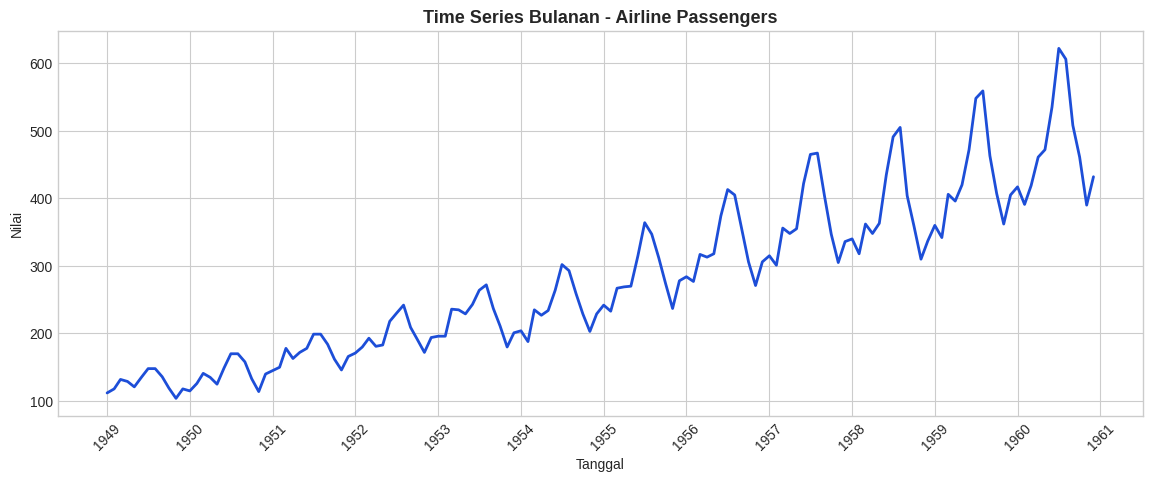

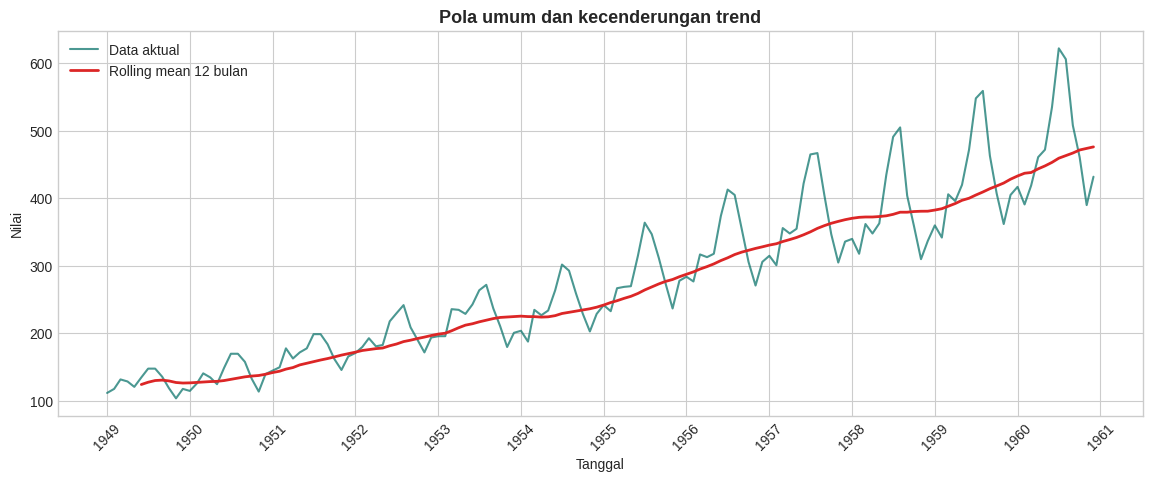

In [63]:
"""Visualisasikan data untuk membaca pola umum time series.

Plot pertama menunjukkan level data aktual sepanjang waktu.
Plot kedua menambahkan rolling mean 12 bulan untuk membantu membaca arah
trend jangka menengah.
"""
# Plot 1: seri waktu aktual.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["value"], color="#1d4ed8", linewidth=2)
ax.set_title(f"Time Series Bulanan - {selected_dataset}", fontsize=13, weight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Nilai")
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()

# Plot 2: data aktual ditambah rolling mean 12 bulan.
rolling_mean = df["value"].rolling(window=12, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["value"], label="Data aktual", color="#0f766e", alpha=0.75)
ax.plot(df["date"], rolling_mean, label="Rolling mean 12 bulan", color="#dc2626", linewidth=2)
ax.set_title("Pola umum dan kecenderungan trend", fontsize=13, weight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Nilai")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()


## Sel 6 - Identifikasi Pola Data

In [64]:
"""Identifikasi pola dominan data secara heuristik.

Heuristik sederhana ini tidak menggantikan uji statistik formal, tetapi cukup
untuk kebutuhan interpretasi praktikum:
- `trend_strength` membandingkan rata-rata awal dan akhir seri,
- `seasonality_ratio` membandingkan variasi profil bulanan terhadap variasi
  total,
- `cv` memberi gambaran tingkat fluktuasi relatif.
"""
series = df["value"]

trend_strength = abs(series.tail(12).mean() - series.head(12).mean())
overall_std = series.std()
cv = overall_std / series.mean() if series.mean() != 0 else np.nan

month_profile = df.assign(month=df["date"].dt.month).groupby("month")["value"].mean()
seasonality_ratio = month_profile.std() / overall_std if overall_std != 0 else np.nan

if seasonality_ratio >= 0.35:
    dominant_pattern = "musiman"
elif trend_strength >= overall_std * 0.5:
    dominant_pattern = "trend"
else:
    dominant_pattern = "fluktuatif/noisy"

print(f"Perkiraan pola dominan : {dominant_pattern}")
print(f"Trend strength         : {trend_strength:,.4f}")
print(f"Koefisien variasi      : {cv:,.4f}")
print(f"Seasonality ratio      : {seasonality_ratio:,.4f}")

if dominant_pattern == "trend":
    print("Interpretasi: data menunjukkan kecenderungan trend yang cukup jelas, sehingga Holt adalah pilihan yang tepat.")
elif dominant_pattern == "musiman":
    print("Interpretasi: data tampak musiman. Holt tetap dipakai sesuai tugas, tetapi keterbatasannya terhadap seasonality harus dijelaskan.")
else:
    print("Interpretasi: data relatif datar atau noisy. Holt tetap digunakan sesuai keputusan tugas, walau model lain bisa saja lebih cocok.")


Perkiraan pola dominan : trend
Trend strength         : 349.5000
Koefisien variasi      : 0.4280
Seasonality ratio      : 0.3390
Interpretasi: data menunjukkan kecenderungan trend yang cukup jelas, sehingga Holt adalah pilihan yang tepat.


## Sel 7 - Train-Test Split

In [65]:
"""Bagi data menjadi train dan test secara time-aware.

Aturan split:
- train berisi seluruh observasi kecuali 15 periode terakhir,
- test berisi 15 periode terakhir sebagai horizon evaluasi.

Pendekatan ini menjaga urutan waktu dan menghindari data leakage.
"""
train_df = df.iloc[:-FORECAST_HORIZON].copy()
test_df = df.iloc[-FORECAST_HORIZON:].copy()

train = train_df.set_index("date")["value"]
test = test_df.set_index("date")["value"]

print(f"Total data : {len(df)}")
print(f"Train      : {len(train)} observasi")
print(f"Test       : {len(test)} observasi")
print(f"Periode train: {train.index.min().date()} sampai {train.index.max().date()}")
print(f"Periode test : {test.index.min().date()} sampai {test.index.max().date()}")

assert len(test) == FORECAST_HORIZON, "Panjang test set tidak sesuai horizon."


Total data : 144
Train      : 129 observasi
Test       : 15 observasi
Periode train: 1949-01-01 sampai 1959-09-01
Periode test : 1959-10-01 sampai 1960-12-01


## Sel 8 - Fitting Model Holt

In [66]:
"""Latih model Holt dan hasilkan forecast 15 periode.

Notebook ini memakai dua jalur:
- `statsmodels.Holt` jika library tersedia,
- implementasi manual Holt berbasis grid search jika tidak tersedia.

Fungsi manual disertakan agar notebook tetap edukatif dan tetap bisa berjalan
meski lingkungan tidak memiliki `statsmodels`.
"""
def holt_manual_fit_forecast(y: pd.Series, horizon: int) -> tuple[pd.Series, pd.Series, dict]:
    """Cari parameter Holt terbaik dengan grid search sederhana.

    Args:
        y: Deret waktu train dengan index datetime bulanan.
        horizon: Jumlah periode forecast ke depan.

    Returns:
        Tuple berisi fitted series, forecast series, dan kamus parameter terbaik.
    """
    values = y.astype(float).to_numpy()
    n = len(values)
    best = None

    alphas = np.arange(0.1, 1.0, 0.1)
    betas = np.arange(0.1, 1.0, 0.1)

    for alpha in alphas:
        for beta in betas:
            level = np.zeros(n)
            trend = np.zeros(n)
            fitted = np.full(n, np.nan)

            # Inisialisasi level dan trend awal memakai dua titik pertama.
            level[0] = values[0]
            trend[0] = values[1] - values[0] if n > 1 else 0.0

            for t in range(1, n):
                fitted[t] = level[t - 1] + trend[t - 1]
                level[t] = alpha * values[t] + (1 - alpha) * (level[t - 1] + trend[t - 1])
                trend[t] = beta * (level[t] - level[t - 1]) + (1 - beta) * trend[t - 1]

            mae = np.mean(np.abs(values[1:] - fitted[1:]))
            if best is None or mae < best["mae"]:
                future = np.array([level[-1] + (h + 1) * trend[-1] for h in range(horizon)])
                best = {
                    "alpha": alpha,
                    "beta": beta,
                    "mae": mae,
                    "fitted": fitted,
                    "forecast": future,
                }

    fitted_series = pd.Series(best["fitted"], index=y.index, name="fitted")
    future_index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    forecast_series = pd.Series(best["forecast"], index=future_index, name="forecast")
    return fitted_series, forecast_series, best


if STATSMODELS_AVAILABLE:
    holt_model = Holt(train, initialization_method="estimated")
    holt_fit = holt_model.fit(optimized=True)
    fitted_values = holt_fit.fittedvalues
    forecast_values = holt_fit.forecast(FORECAST_HORIZON)
    model_info = {
        "method": "statsmodels.Holt",
        "alpha": holt_fit.params.get("smoothing_level"),
        "beta": holt_fit.params.get("smoothing_trend"),
    }
else:
    fitted_values, forecast_values, best_params = holt_manual_fit_forecast(train, FORECAST_HORIZON)
    model_info = {
        "method": "manual Holt grid search",
        "alpha": best_params["alpha"],
        "beta": best_params["beta"],
    }

print("Model yang dipakai:", model_info["method"])
print(f"alpha              : {model_info['alpha']}")
print(f"beta               : {model_info['beta']}")

display(forecast_values.to_frame(name="forecast"))


Model yang dipakai: statsmodels.Holt
alpha              : 0.9999999850988388
beta               : 0.0


,forecast
1959-10-01,465.7422
1959-11-01,468.4844
1959-12-01,471.2266
1960-01-01,473.9688
1960-02-01,476.7110
1960-03-01,479.4532
1960-04-01,482.1953
1960-05-01,484.9375
1960-06-01,487.6797
1960-07-01,490.4219


## Sel 9 - Forecast 15 Periode ke Depan

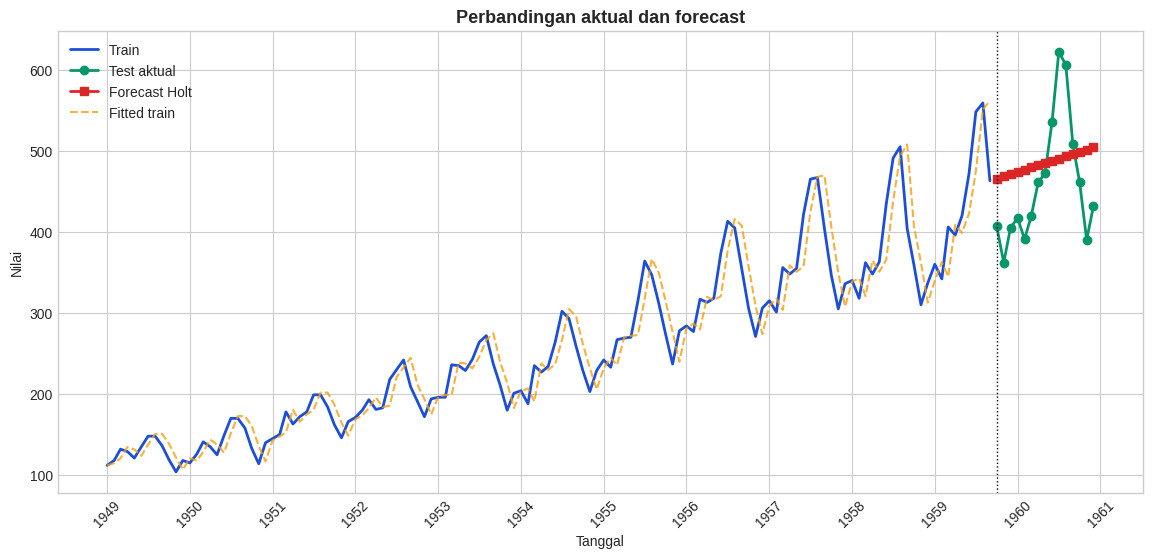

In [67]:
"""Visualisasikan hasil forecast terhadap data train dan test.

Plot ini dipakai untuk membaca:
- kecocokan fitted value pada train,
- posisi forecast terhadap data aktual test,
- titik awal periode evaluasi out-of-sample.
"""
assert len(forecast_values) == FORECAST_HORIZON, "Forecast tidak menghasilkan 15 periode."

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train.values, label="Train", color="#1d4ed8", linewidth=2)
ax.plot(test.index, test.values, label="Test aktual", color="#059669", linewidth=2, marker="o")
ax.plot(forecast_values.index, forecast_values.values, label="Forecast Holt", color="#dc2626", linewidth=2, marker="s")
ax.plot(fitted_values.index, fitted_values.values, label="Fitted train", color="#f59e0b", linewidth=1.5, linestyle="--", alpha=0.8)
ax.axvline(test.index.min(), color="black", linestyle=":", linewidth=1)
ax.set_title("Perbandingan aktual dan forecast", fontsize=13, weight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Nilai")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()


## Sel 10 - Evaluasi Error

In [68]:
"""Hitung metrik evaluasi forecast pada data test.

Metrik utama:
- `MAE` sebagai rata-rata selisih absolut.

Metrik tambahan:
- `MAPE` jika nilai aktual tidak mendekati nol.

Selain metrik agregat, blok ini juga membuat tabel perbandingan aktual versus
forecast untuk tiap periode test.
"""
comparison_df = pd.DataFrame({
    "actual": test,
    "forecast": forecast_values,
})
comparison_df["abs_error"] = (comparison_df["actual"] - comparison_df["forecast"]).abs()
comparison_df["pct_error"] = np.where(
    comparison_df["actual"].abs() > 1e-9,
    comparison_df["abs_error"] / comparison_df["actual"].abs() * 100,
    np.nan,
)

mae = comparison_df["abs_error"].mean()
mape = comparison_df["pct_error"].mean()

print(f"MAE  : {mae:,.4f}")
print(f"MAPE : {mape:,.4f}" if pd.notna(mape) else "MAPE : tidak dihitung karena ada nilai aktual mendekati nol.")

assert np.isfinite(mae), "MAE gagal dihitung."
assert len(forecast_values) == FORECAST_HORIZON, "Forecast horizon tidak tepat."

display(comparison_df)


MAE  : 66.2479
MAPE : 14.7983


,actual,forecast,abs_error,pct_error
1959-10-01,407,465.7422,58.7422,14.4330
1959-11-01,362,468.4844,106.4844,29.4156
1959-12-01,405,471.2266,66.2266,16.3522
1960-01-01,417,473.9688,56.9688,13.6616
1960-02-01,391,476.7110,85.7110,21.9210
1960-03-01,419,479.4532,60.4532,14.4280
1960-04-01,461,482.1953,21.1953,4.5977
1960-05-01,472,484.9375,12.9375,2.7410
1960-06-01,535,487.6797,47.3203,8.8449
1960-07-01,622,490.4219,131.5781,21.1540


## Sel 11 - Interpretasi Hasil

In [69]:
"""Bangun interpretasi otomatis berdasarkan pola data dan metrik model.

Bagian ini menulis narasi singkat yang bisa langsung dipakai sebagai bahan
laporan praktikum. Fokus utama tetap pada pola data, kecocokan Holt, dan
batasan model terhadap seasonality.
"""
print("Interpretasi hasil praktikum")
print("-" * 60)
print(f"Dataset yang digunakan : {selected_dataset}")
print(f"Jumlah observasi       : {len(df)}")
print(f"Pola dominan           : {dominant_pattern}")
print(f"Model                  : {model_info['method']}")
print(f"MAE                    : {mae:,.4f}")

if pd.notna(mape):
    print(f"MAPE                   : {mape:,.4f}%")

print("\nAnalisis:")

if dominant_pattern == "trend":
    print("1. Data memiliki trend yang cukup jelas, sehingga metode Holt relevan karena memang dirancang untuk menangkap level dan trend.")
elif dominant_pattern == "musiman":
    print("1. Data cenderung musiman. Holt tetap dapat dipakai, tetapi tidak memodelkan komponen musiman secara eksplisit seperti Holt-Winters.")
else:
    print("1. Data cenderung datar atau noisy. Holt tetap digunakan sesuai keputusan tugas, walau metode lain dapat dipertimbangkan pada studi lanjutan.")

print("2. Nilai MAE menunjukkan rata-rata selisih absolut antara forecast dan data aktual pada 15 periode terakhir.")
print("3. Kelebihan Holt adalah sederhana, cepat, dan mudah dijelaskan dalam laporan praktikum.")
print("4. Keterbatasan Holt adalah tidak secara eksplisit memodelkan seasonality dan sensitif terhadap perubahan pola yang mendadak.")


Interpretasi hasil praktikum
------------------------------------------------------------
Dataset yang digunakan : Airline Passengers
Jumlah observasi       : 144
Pola dominan           : trend
Model                  : statsmodels.Holt
MAE                    : 66.2479
MAPE                   : 14.7983%

Analisis:
1. Data memiliki trend yang cukup jelas, sehingga metode Holt relevan karena memang dirancang untuk menangkap level dan trend.
2. Nilai MAE menunjukkan rata-rata selisih absolut antara forecast dan data aktual pada 15 periode terakhir.
3. Kelebihan Holt adalah sederhana, cepat, dan mudah dijelaskan dalam laporan praktikum.
4. Keterbatasan Holt adalah tidak secara eksplisit memodelkan seasonality dan sensitif terhadap perubahan pola yang mendadak.


## Sel 12 - Kesimpulan

In [70]:
"""Ringkas hasil praktikum ke dalam poin kesimpulan akhir.

Poin ini bisa dipakai langsung pada bagian penutup laporan karena sudah memuat
horizon forecast, dataset, status validasi data, metrik utama, dan catatan
kecocokan model terhadap pola data.
"""
conclusion_lines = [
    f"Notebook berhasil membangun pipeline forecasting bulanan berbasis metode Holt dengan horizon {FORECAST_HORIZON} periode.",
    f"Dataset final yang dipakai adalah {selected_dataset}.",
    f"Semua validasi data inti lolos, termasuk observasi minimal {MIN_OBSERVATIONS}, parsing tanggal, urutan waktu, dan tidak adanya duplikasi bulan.",
    f"Metrik utama yang digunakan adalah MAE = {mae:,.4f}.",
]

if dominant_pattern == "musiman":
    conclusion_lines.append("Karena data cenderung musiman, hasil Holt perlu dibaca dengan catatan bahwa model ini tidak menangkap musim secara eksplisit.")
elif dominant_pattern == "trend":
    conclusion_lines.append("Karena data memiliki trend yang cukup jelas, Holt menjadi pilihan yang sesuai untuk praktikum ini.")
else:
    conclusion_lines.append("Karena data relatif fluktuatif, hasil Holt tetap valid untuk tugas, walau bukan satu-satunya pendekatan yang mungkin.")

for i, line in enumerate(conclusion_lines, start=1):
    print(f"{i}. {line}")


1. Notebook berhasil membangun pipeline forecasting bulanan berbasis metode Holt dengan horizon 15 periode.
2. Dataset final yang dipakai adalah Airline Passengers.
3. Semua validasi data inti lolos, termasuk observasi minimal 100, parsing tanggal, urutan waktu, dan tidak adanya duplikasi bulan.
4. Metrik utama yang digunakan adalah MAE = 66.2479.
5. Karena data memiliki trend yang cukup jelas, Holt menjadi pilihan yang sesuai untuk praktikum ini.
